In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q transformers pandas scikit-learn scipy tqdm matplotlib accelerate

import os, json, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from google.colab import drive

In [3]:
# ================= CONFIG =================

MODEL_NAME = "albert-base-v2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_LEN = 512
BATCH = 2
ACCUM = 8
EPOCHS = 11
LR = 1e-5
WEIGHT_DECAY = 0.01
PATIENCE = 3
MULTIPLIER = 6

TRAITS = ["openness","conscientiousness","extraversion","agreeableness","neuroticism"]

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Project_One/pandora_user_level_paper_108.parquet"
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Project_One/albert_personality_model"

drive.mount("/content/drive")
os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ================= LOAD DATA =================

df = pd.read_parquet(DATA_PATH)
df = df.dropna(subset=TRAITS).reset_index(drop=True)
df["uid"] = df.index

print("Users:",len(df))

trait_means = df[TRAITS].mean()
trait_stds = df[TRAITS].std() + 1e-6
df[TRAITS]=(df[TRAITS]-trait_means)/trait_stds

train_df,val_df=train_test_split(df,test_size=0.2,random_state=42)

tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)

Users: 1484


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

In [5]:
# ================= DATASET =================

class Pandora(Dataset):
    def __init__(self,df):
        self.text=df.text.tolist()
        self.y=df[TRAITS].values.astype(np.float32)
        self.u=df.uid.tolist()

    def __len__(self): return len(self.text)*MULTIPLIER

    def __getitem__(self,i):
        i%=len(self.text)
        t=self.text[i]
        w=t.split()
        if len(w)>800:
            s=random.randint(0,len(w)-800)
            t=" ".join(w[s:s+800])

        enc=tokenizer(t,truncation=True,max_length=MAX_LEN,padding="max_length",return_tensors="pt")
        y=torch.tensor(self.y[i])*0.9   # label smoothing

        return enc["input_ids"].squeeze(),enc["attention_mask"].squeeze(),y,torch.tensor(self.u[i])

train_loader=DataLoader(Pandora(train_df),batch_size=BATCH,shuffle=True)
val_loader=DataLoader(Pandora(val_df),batch_size=BATCH)

In [6]:
# ================= MODEL =================

class AlbertReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc=AutoModel.from_pretrained(MODEL_NAME)
        self.enc.config.hidden_dropout_prob=0.3
        self.enc.config.attention_probs_dropout_prob=0.3

        h=self.enc.config.hidden_size
        self.att=nn.Linear(h,1)
        self.fc=nn.Sequential(nn.Linear(h,128),nn.ReLU(),nn.Dropout(0.4))
        self.heads=nn.ModuleList([nn.Linear(128,1) for _ in range(5)])

    def forward(self,i,m):
        x=self.enc(i,attention_mask=m).last_hidden_state
        w=torch.softmax(self.att(x),1)
        x=(x*w).sum(1)
        x=self.fc(x)
        return torch.cat([h(x) for h in self.heads],1)

model=AlbertReg().to(DEVICE)

for p in model.enc.parameters(): p.requires_grad=False

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
# ================= OPTIM =================

loss_fn=nn.SmoothL1Loss()
opt=AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
steps=(len(train_loader)*EPOCHS)//ACCUM
sched=get_cosine_schedule_with_warmup(opt,0,steps)
scaler=torch.cuda.amp.GradScaler()

/tmp/ipython-input-422/3220810771.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=torch.cuda.amp.GradScaler()


In [8]:
# ================= TRAIN =================

best=1e9; bad=0
train_hist=[]; val_hist=[]

for ep in range(EPOCHS):

    if ep==3:
        for l in model.enc.encoder.albert_layer_groups[-1:]:
            for p in l.parameters(): p.requires_grad=True
    if ep==5:
        for p in model.enc.parameters(): p.requires_grad=True

    model.train(); opt.zero_grad()
    ls=[]

    for s,(i,m,y,_) in enumerate(tqdm(train_loader)):
        i,m,y=i.to(DEVICE),m.to(DEVICE),y.to(DEVICE)
        with torch.cuda.amp.autocast():
            loss=loss_fn(model(i,m),y)/ACCUM
        scaler.scale(loss).backward()

        if (s+1)%ACCUM==0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(),1)
            scaler.step(opt); scaler.update(); sched.step(); opt.zero_grad()

        ls.append(loss.item()*ACCUM)

    tr=np.mean(ls)

    model.eval(); vs=[]
    with torch.no_grad():
        for i,m,y,_ in val_loader:
            vs.append(loss_fn(model(i.to(DEVICE),m.to(DEVICE)),y.to(DEVICE)).item())

    vl=np.mean(vs)
    train_hist.append(tr); val_hist.append(vl)

    print(f"Epoch {ep+1} | Train {tr:.3f} | Val {vl:.3f}")

    if vl<best:
        best=vl; bad=0
        torch.save(model.state_dict(),f"{SAVE_DIR}/model.pt")
    else:
        bad+=1
        if bad>=PATIENCE:
            print("Early stop"); break

  0%|          | 0/3561 [00:00<?, ?it/s]/tmp/ipython-input-422/3754036683.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 3561/3561 [02:33<00:00, 23.17it/s]


Epoch 1 | Train 0.387 | Val 0.381


100%|██████████| 3561/3561 [02:16<00:00, 26.02it/s]


Epoch 2 | Train 0.382 | Val 0.379


100%|██████████| 3561/3561 [02:16<00:00, 26.11it/s]


...

Epoch 7 | Train 0.337 | Val 0.367


100%|██████████| 3561/3561 [05:22<00:00, 11.03it/s]


Epoch 8 | Train 0.331 | Val 0.369


100%|██████████| 3561/3561 [05:25<00:00, 10.94it/s]


Epoch 9 | Train 0.324 | Val 0.370
Early stop


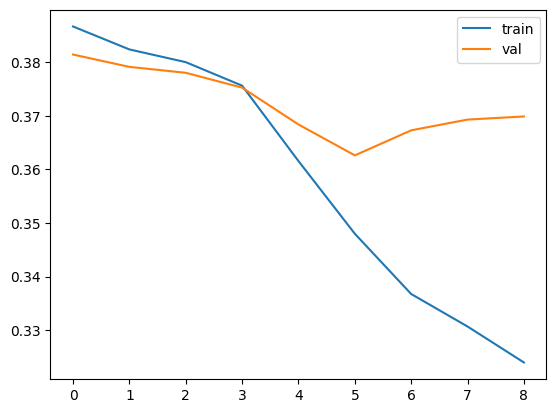

In [9]:
# ================= CURVES =================

plt.plot(train_hist); plt.plot(val_hist); plt.legend(["train","val"]); plt.show()


In [10]:
# ================= METRICS =================

model.load_state_dict(torch.load(f"{SAVE_DIR}/model.pt"))
model.eval()

P=defaultdict(list); T={}

with torch.no_grad():
    for i,m,y,u in val_loader:
        o=model(i.to(DEVICE),m.to(DEVICE)).cpu()
        for k,uid in enumerate(u):
            P[uid.item()].append(o[k])
            T[uid.item()]=y[k]

X=[];Y=[]
for u in P:
    X.append(torch.stack(P[u]).mean(0))
    Y.append(T[u])

X=torch.stack(X).numpy()*trait_stds.values+trait_means.values
Y=torch.stack(Y).numpy()*trait_stds.values+trait_means.values

print("\n=== FINAL ALBERT METRICS ===")

for i,t in enumerate(TRAITS):
    mae=mean_absolute_error(Y[:,i],X[:,i])
    mse=mean_squared_error(Y[:,i],X[:,i])
    rmse=np.sqrt(mse)
    r=pearsonr(Y[:,i],X[:,i])[0]
    print(t,"MAE",mae,"MSE",mse,"RMSE",rmse,"R",r)

print("\nMacro MAE:",mean_absolute_error(Y,X))
print("Macro MSE:",mean_squared_error(Y,X))
print("Macro RMSE:",np.sqrt(mean_squared_error(Y,X)))
print("R2:",r2_score(Y,X))



=== FINAL ALBERT METRICS ===
openness MAE 19.99861362162568 MSE 570.6021460663854 RMSE 23.887280005609377 R 0.31083361765141493
conscientiousness MAE 22.995015250106785 MSE 715.6728487198485 RMSE 26.752062513381066 R 0.19692154767873726
extraversion MAE 23.236386220315506 MSE 733.5858453908065 RMSE 27.084789927020047 R 0.23373803325448464
agreeableness MAE 22.9486906140716 MSE 718.3042721622918 RMSE 26.80119908068092 R 0.26794716308144273
neuroticism MAE 24.11360443254264 MSE 766.6084384990282 RMSE 27.687694712616075 R 0.28171537670348973

Macro MAE: 22.658462027732448
Macro MSE: 700.9547101676719
Macro RMSE: 26.47554928925313
R2: 0.059496050044517926


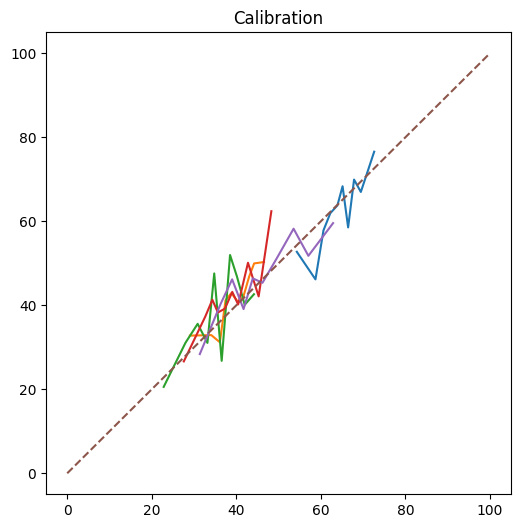

In [11]:
# ================= CALIBRATION =================

def calib(a,b):
    idx=np.argsort(b);a=a[idx];b=b[idx]
    s=len(a)//10
    return [b[i*s:(i+1)*s].mean() for i in range(10)], [a[i*s:(i+1)*s].mean() for i in range(10)]

plt.figure(figsize=(6,6))
for i in range(5):
    xs,ys=calib(Y[:,i],X[:,i])
    plt.plot(xs,ys)

plt.plot([0,100],[0,100],'--')
plt.title("Calibration")
plt.show()

In [12]:
# ================= SAVE BUNDLE =================

tokenizer.save_pretrained(SAVE_DIR)

with open(f"{SAVE_DIR}/norm.json","w") as f:
    json.dump({t:{"mean":float(trait_means[t]),"std":float(trait_stds[t])} for t in TRAITS},f,indent=2)

print("✅ Full model saved:",SAVE_DIR)

✅ Full model saved: /content/drive/MyDrive/Colab Notebooks/Project_One/albert_personality_model
